# Plot the rupture profile on the slip velocity

2024.6.19 Kurama Okubo

Plot the rupture profile on the slip velocity.

In [145]:
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.colors as colors

%matplotlib inline
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings
import time

from importParaviewColormap import importParaviewColormap


%load_ext autoreload
%autoreload 2

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True

plt.rcParams['axes.linewidth'] = 0.75

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
figdir = "../figure/05_ruptureprofile"
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [147]:
E = 96e9
nu = 0.246 # metagabbro
mu = E/(2*(1+nu))

a_patch = 4.2e-3
a_nuc = 2.5e-3 # nucleation radius 

nb_x_elements = 128 #128
nb_z_elements = 128 #128

IfBinaryOutput = True

read_dumpedpickle = False # false if you first run the notebook

In [148]:
# case study parameter casename

a_patch = 4.0e-3
a_nuc = 2.5e-3
a_margin = 4.08e-3

rupturetype = "crack"
pdcscaling = 0.56 #0.65
bgbeta=0.4

nb_x_elements = 128 #128 #128
nb_z_elements = 128 #128 #128

IfBinaryOutput = True

casestr = f"a={a_patch*1e3:.2f}_ruptype={rupturetype}_pdcscaling={pdcscaling:.3f}_sn=8.0MPa_hatfr=0.3_bgbeta={bgbeta:.2f}"

finame=f"../../preprocess_modelsetup/data/gouge_dynamicrupture_modelparam_{casestr}.csv"

# Read model parameters
df_modelparam = pd.read_csv(finame, index_col=0)

datadir_root = "../../../uguca/build_v34_mastercases_coarse/simulations_main_casestudy"

casestr

'a=4.00_ruptype=crack_pdcscaling=0.560_sn=8.0MPa_hatfr=0.3_bgbeta=0.40'

In [149]:
df_modelparam.head()

,M0_mean,Tw_mean,Mw_mean,hat_sn_patch,hat_sn_background,delsig_withmargin_try,slip_try,initialstress_fraction,delsigma_factor,fp_patch,...,GIIC_patch,GIIC_background,Sratio_nuc,Sratio_patch,Ainit_nuc,Ainit_patch,Anuc_nuc,Anuc_patch,rnuc_nuc,rnuc_patch
datacase,,,,,,,,,,,,,,,,,,,,,
fb03-087__0036,0.085760,2.6196,-6.781143,8000000.0,2000000.0,552436.655,4.256881e-08,0.942,0.647,0.365901,...,0.004602,0.0,0,0.475001,3.82,4.036047,0.000006,0.000007,1.406808,1.446043
fb03-087__0035,0.228892,2.5935,-6.496912,8000000.0,2000000.0,1474446.690,1.136156e-07,0.940,0.560,0.428948,...,0.015605,0.0,0,0.249361,3.82,3.855329,0.000005,0.000005,1.245842,1.251589
fb03-087__0030,0.334288,2.2370,-6.387253,8000000.0,2000000.0,2153367.530,1.659309e-07,0.925,0.450,0.455272,...,0.023230,0.0,0,0.281898,3.82,3.869865,0.000005,0.000005,1.279080,1.287401
fb03-087__0071,0.518240,2.5690,-6.260313,8000000.0,2000000.0,3338323.980,2.572394e-07,0.925,0.450,0.527331,...,0.043476,0.0,0,0.210617,3.82,3.841981,0.000004,0.000004,1.116770,1.119979
fb03-087__0043,0.551521,2.6905,-6.242292,8000000.0,2000000.0,3552705.790,2.737589e-07,0.925,0.450,0.540367,...,0.047600,0.0,0,0.202800,3.82,3.839765,0.000004,0.000004,1.093663,1.096489


In [150]:
# Select gouge event id to plot the snapshots
expr_id = "fb03-087"
gougeevent_id = 104

In [151]:
df_modelparam_selected = df_modelparam[df_modelparam.index == f"fb03-087__{gougeevent_id:04d}"]
simulation_name = df_modelparam_selected.index[0]+f"_{casestr}"
print(f"Process {gougeevent_id}: {simulation_name}")


Process 104: fb03-087__0104_a=4.00_ruptype=crack_pdcscaling=0.560_sn=8.0MPa_hatfr=0.3_bgbeta=0.40


In [152]:
figdir_profile_master = f"{figdir}/{simulation_name}"
if not os.path.exists(figdir_profile_master):
    os.makedirs(figdir_profile_master)

## Set the model parameters

In [153]:
df_time = pd.read_csv(os.path.join(datadir_root,simulation_name+".time"), header=None, sep=' ', index_col=0)
df_coord = pd.read_csv(os.path.join(datadir_root,simulation_name+".coords"), header=None, sep=' ', index_col=None)
NT=len(df_time)


In [154]:
R_nuc = df_modelparam_selected.rnuc_patch.values[0]*1e-3 
Lc = 2*R_nuc # [m] we define the Lc as the diameter of the nucleation circle

In [155]:
# location of the center of nucleation zone
nuc_x = -(a_patch - a_nuc)
nuc_z = 0

xcoord = df_coord.loc[:,0].values
zcoord = df_coord.loc[:,2].values

x_length = xcoord.max()
z_length = zcoord.max()

# ref also: https://stackoverflow.com/a/35176314

X = xcoord.reshape(nb_x_elements,nb_z_elements).T - x_length/2
Z = zcoord.reshape(nb_x_elements,nb_z_elements).T - z_length/2

dz = (zcoord[1] - zcoord[0])
print(f"Grid size: {dz*1e3}[mm]") 

Grid size: 0.3125[mm]


## Read data

In [156]:
read_comp = 0 #0: Mode II direction, 1: normal (Mode I), 2:Mode III direction 

# read velocity
read_parameter = f"top_velo_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_vel = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_vel = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")
    
# read displacement
read_parameter = f"top_disp_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_disp = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_disp = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")

# read cohesion (shear traction)
read_parameter = f"cohesion_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_coh = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_coh = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")


# check if the grid size is consistent to the data shape
assert len(df_data_vel.columns) == len(xcoord)
assert len(df_data_disp.columns) == len(xcoord)
assert len(df_data_coh.columns) == len(xcoord)


# Compute the rupture profile
Process flow:

1. extract the data along x axis
2. plot x-t axis

In [157]:
center_z = zcoord[np.where(zcoord-z_length/2>0)[0][0]]
center_x_index = df_coord[df_coord[2] == center_z].index

In [158]:
df_data_vel_x = df_data_vel.loc[:, center_x_index]
df_data_disp_x = df_data_disp.loc[:, center_x_index]
df_data_coh_x = df_data_coh.loc[:, center_x_index]

In [159]:
xcoord_vec = np.unique(xcoord)
xq, tq = np.meshgrid(xcoord_vec-x_length/2, df_time)

In [160]:
tq.shape

(307, 128)

In [161]:
2*df_data_vel.max().max(), 2*df_data_vel.min().min(), 2*df_data_disp.max().max()*1e6, df_data_coh.max().max()/1e6

(1.327883243560791, -0.026058951392769814, 0.597650284817064, 6.2658385)

In [162]:
cmap_vel = importParaviewColormap("pararainbow_uni_w"+".json", False)


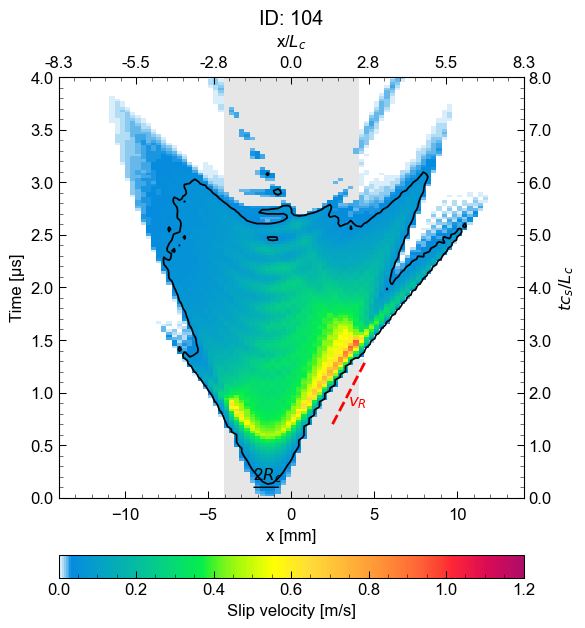

In [163]:
cs = 3600

vmax_vel = 1.2
vmin_vel = 0.0 #-0.5

xlimit = [-6, 6]
ylimit = [0, 4]

value_factor_double = 2.0 # double the value for slip and slip velocity

patch_highlight = True

fig, [ax, cax] = plt.subplots(2, 1, figsize=(6, 6.5), gridspec_kw={'height_ratios': [0.95, 0.05]})
fig.subplots_adjust(hspace=0.26)

# contourf was tricky to define the color range
# levels = 100
# levels = np.linspace(vmin_vel, vmax_vel, 101)
# h1 = ax.contourf(xq*1e3, tq*1e6, value_factor_double*df_data_vel_x, levels, norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel), cmap='turbo') # multiply 2 for slip velocity
# for c in h1.collections:
    # c.set_rasterized(True)

# Plot patch width
# ax.plot([a_patch*1e3, a_patch*1e3], [0, 8], "--", c="gray", lw=1)
# ax.plot([-a_patch*1e3, -a_patch*1e3], [0, 8], "--", c="gray", lw=1)
# ax.axvspan(-a_patch*1e3,  a_patch*1e3, alpha=0.5, color='red')

# Set small values to highlight patch area
# Note: In this plot, we ignored the negative slip velocity although almost no negative slip exists.
data_vel_x_filled = np.zeros(df_data_vel_x.shape)
vel_eps = 0.002
for i, data in df_data_vel_x.iterrows():
    # set small velocity in the patch
    if patch_highlight:
        data.values[(2*data.values < vel_eps)] = vel_eps
        data.values[(np.abs(xq[0]) < a_patch) & (2*data.values < 10*vel_eps)] = -100
        
    data_vel_x_filled[i, :] = data.values

cmap_vel.set_under([0.9, 0.9, 0.9])

h1 = ax.pcolormesh(xq*1e3, tq*1e6, value_factor_double*data_vel_x_filled, #value_factor_double*df_data_vel_x,
                   norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel),
                   cmap=cmap_vel, rasterized=True) # multiply 2 for slip velocity

# plot contour line
contour_levels=[0.05]
h2 = ax.contour(xq*1e3, tq*1e6, value_factor_double*df_data_vel_x, levels=contour_levels,
               colors="k", linewidths=1.25) # multiply 2 for slip velocity

def fmt(x):
    return f"{x:.2g}" # mm/s"

# ref: https://stackoverflow.com/a/13015194
# manual_locations = [(2, 0.6), (2, 1), (-2, 0.5), (1.7, 1.2)]
# ax.clabel(h2, h2.levels, inline=False, fmt=fmt, fontsize=12, manual=manual_locations)

# adjust the location of annotation
if gougeevent_id==91:
    annot_loc = [(2.35, 0.55), (0.85, 1.0), (0.3, 2.025), (0.18, 2.525)]
elif gougeevent_id==30:
    annot_loc = [(2.35, 0.55), (1.5, 1.45), (0.5, 2.275), (0.18, 2.725)]
else:
    annot_loc = [(2.425, 0.55), (1.2, 0.95), (0.3, 1.775), (0.18, 2.25)]


# for i, lev in enumerate(contour_levels):
#     ax.text(annot_loc[i][0], annot_loc[i][1], fmt(lev), color="k")

# ax.text(2.375, 0.35, "[mm/s]")
ax.set_title(f"ID: {gougeevent_id}")
ax.set_xlim([-14, 14])
ax.set_ylim(ylimit)
ax.set_xlabel("x [mm]")
ax.set_ylabel("Time [μs]")

# plot reference of rupture speed
vscale_len = 2;
v_dt = 1; #[us]
v_x0= 2.5; #[mm]
v_t0= 0.7; #[us]

dx_cs = (cs*1e-3)*v_dt; # compute with [mm/us]
dx_cr = 0.92*(cs*1e-3)*v_dt;

# th_vp = np.arctan2(dx_vp, v_dt);
th_vs = np.arctan2(v_dt, dx_cs);
th_vr = np.arctan2(v_dt, dx_cr);

# plot([v_t0, v_t0+vscale_len/tan(th_vp)], [v_x0, v_x0-vscale_len], "k-")
# ax.plot([v_x0, v_x0+vscale_len], [v_t0, v_t0+vscale_len*np.tan(th_vs)], "k-")
ax.plot([v_x0, v_x0+vscale_len], [v_t0, v_t0+vscale_len*np.tan(th_vr)], "--", c="r", lw=2)

# text(6, 0.92, "c_p", "FontSize",17);
# ax.text(6.7, 0.92, "c_s");
ax.text(4.0, 0.88, "$v_R$", ha="center", c="r");

# plot nucleation zone
refy = 0.1
ax.annotate('', xy=((nuc_x - R_nuc)*1e3, refy), xytext=((nuc_x + R_nuc)*1e3, refy),
            arrowprops=dict(arrowstyle='-'), annotation_clip=True)
annotstr = r" 2$R_c$"
ax.text(nuc_x*1e3, 0.13, annotstr, ha="center", va='bottom')
# # axs[1].plot([refstarttime, refendtime], [-0.3, -0.3], clip_on=False,)

# plot twin axes for the non dimensional values

ax.tick_params(axis='x', which='major', pad=7)

# nondimensional space
def x2nondim(x, Lc):
    return x/Lc

ax2 = ax.twiny()
ax2.set_xlim(xlimit) # synchronize with the first axis
ax2_xticks = ax.get_xticks()
ax2.set_xticks(ax2_xticks, labels=[f"{x:.1f}" for x in x2nondim(ax2_xticks*1e-3, Lc)])
ax2.tick_params(axis='x', pad=5)

xlabelstr2 = r"x/$L_c$"
ax2.set_xlabel(xlabelstr2, labelpad=6)

# nondimensional time
def t2nondim(t, cs, Lc):
    return t*cs/Lc
    
ax3 = ax.twinx()
ax3.set_ylim(ylimit) # synchronize with the first axis
ax3_yticks = ax.get_yticks()
ax3.set_yticks(ax3_yticks, labels=[f"{x:.1f}" for x in t2nondim(ax3_yticks*1e-6, cs, Lc)])


ylabelstr3 = r"$tc_s/L_c$"
ax3.set_ylabel(ylabelstr3)

cb_vel = fig.colorbar(h1, cax=cax, orientation="horizontal", shrink=1.0, norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel) )#ticks=cticks)
cb_vel.set_label("Slip velocity [m/s]")


plt.savefig(figdir_profile_master + "/master_ruptureprofile_{}_comp{}.png".format(simulation_name, read_comp), dpi=300, bbox_inches="tight")
plt.savefig(figdir_profile_master + "/master_ruptureprofile_{}_comp{}.pdf".format(simulation_name, read_comp), bbox_inches="tight")


In [164]:
x = df_data_vel_x.values[np.abs(xq) <= a_patch]

# Plot displacement profile

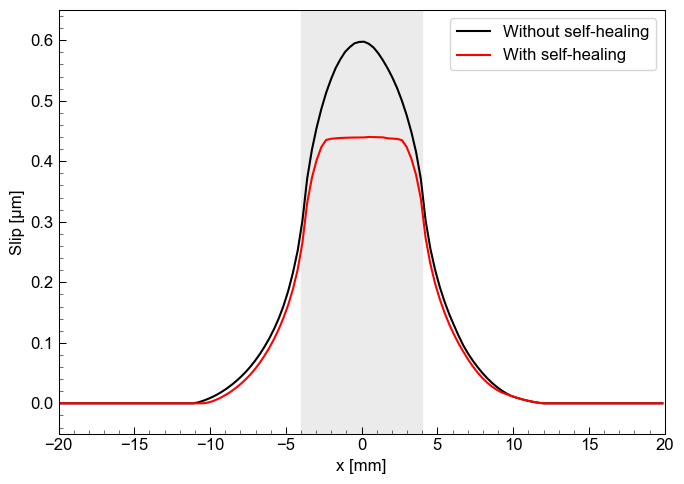

In [165]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

Ifplotpulseresult=True # If you run the pulse case, you can compare the result with Ifplotpulseresult=True.

xvec = xq[0]
tvec = tq[:, 0]
tplot = 4e-6
tind = np.where(tvec > tplot)[0][0]

disp_prof=value_factor_double*df_data_disp_x.loc[tind, :].values

ax.plot(xvec*1e3, disp_prof*1e6, "-", c="k")

if Ifplotpulseresult:
    # run the result of pulse case
    casestr_pulse = f"a={a_patch*1e3:.2f}_ruptype={'pulse'}_pdcscaling={pdcscaling:.3f}_sn=8.0MPa_hatfr=0.3_bgbeta={bgbeta:.2f}"
    df_disp_pulse = pd.read_csv(f"../data/top_half_displacement_{gougeevent_id}_{casestr_pulse}.csv", index_col=0)
    disp_prof_pulse = value_factor_double*df_disp_pulse.loc[tind, :].values

    ax.plot(xvec*1e3, disp_prof_pulse*1e6, "-", c="r", zorder=2)

ax.set_xlim([-20, 20])
ax.set_ylim([-0.05, 0.65])
ax.axvspan(-4, 4, color=[0.92, 0.92, 0.92])

if Ifplotpulseresult:
    ax.legend(["Without self-healing", "With self-healing"], loc=1)

ax.set_xlabel("x [mm]")
ax.set_ylabel("Slip [μm]")

plt.tight_layout()
plt.savefig(figdir_profile_master + f"/slip_profile_{gougeevent_id}_{casestr}_Ifplotpulseresult_{Ifplotpulseresult}.png", dpi=300, bbox_inches="tight")
plt.savefig(figdir_profile_master + f"/slip_profile_{gougeevent_id}_{casestr}_Ifplotpulseresult_{Ifplotpulseresult}.pdf", bbox_inches="tight")


In [166]:
# save displacement profile for the comparison
df_data_disp_x.to_csv(f"../data/top_half_displacement_{gougeevent_id}_{casestr}.csv", index=True)